In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt


In [2]:
data_dir = "./data"
situations_dir = os.path.join(data_dir, "processed")

situation_number = 1
path = os.path.join(situations_dir, f"situation_{situation_number}.csv")


In [ ]:
df = pd.read_csv(path, encoding="utf-8")


In [4]:
counts = (
	df.groupby(["gender", "sexual_orientation"])
	.size()
	.reset_index(name="count")
)

heatmap_data = counts.pivot(
	index="gender",
	columns="sexual_orientation",
	values="count"
).fillna(0)


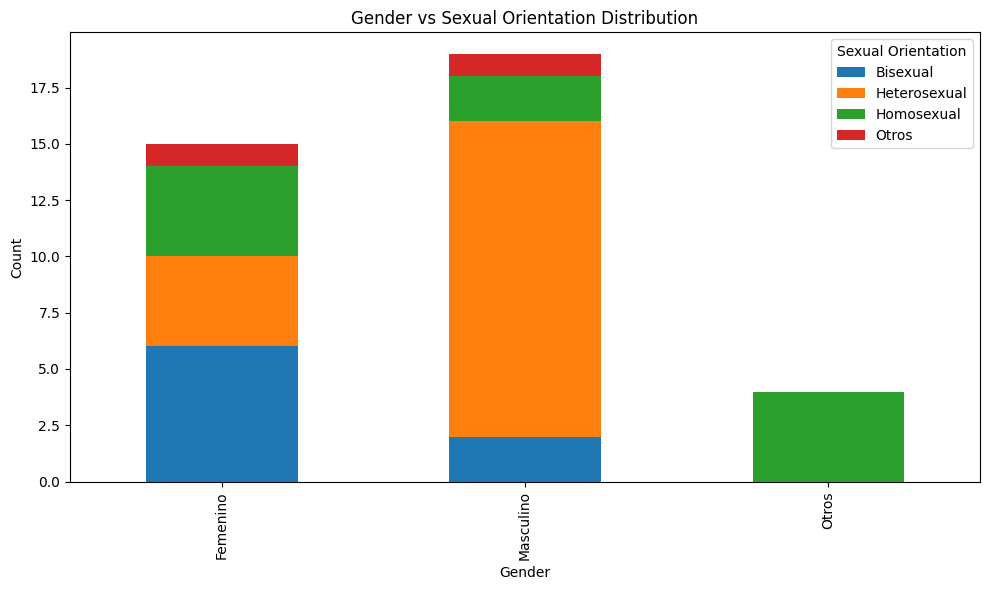

In [5]:
ax = heatmap_data.plot(
	kind="bar",
	stacked=True,
	figsize=(10, 6)
)

plt.title("Gender vs Sexual Orientation Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Sexual Orientation")
plt.tight_layout()

plt.show()


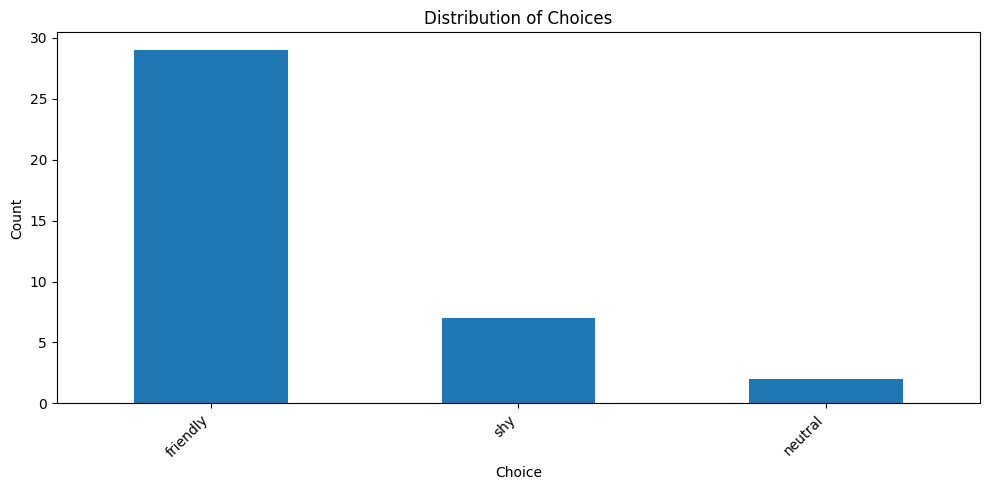

In [6]:
if "choice" in df:
	choice_counts = df["choice"].value_counts()

	max_words = 30
	choice_counts.index = [
		(c[:max_words] + "...") if len(c) > max_words else c
		for c in choice_counts.index
	]

	plt.figure(figsize=(10, 5))
	choice_counts.plot(kind="bar")

	plt.title("Distribution of Choices")
	plt.xlabel("Choice")
	plt.ylabel("Count")
	plt.xticks(rotation=45, ha="right")

	plt.tight_layout()
	plt.show()
